## 🌾 Machine Learning: Crop Recommendation System

### 📚 Deskripsi Dataset

Pada studi kasus ini, kita akan membuat **sistem rekomendasi tanaman** berbasis **Machine Learning** yang bertujuan membantu petani dalam menentukan jenis tanaman terbaik berdasarkan kondisi lingkungan dan tanah.

Dataset yang digunakan berisi **data agrikultur** dengan berbagai parameter penting yang mempengaruhi pertumbuhan tanaman. Data ini mencakup **unsur hara tanah (N, P, K)**, **suhu**, **kelembaban udara**, **tingkat keasaman tanah (pH)**, dan **curah hujan**. Berdasarkan parameter-parameter ini, sistem akan memberikan **rekomendasi jenis tanaman** yang paling sesuai.

Berikut adalah deskripsi dari setiap kolom dalam dataset:

| **Kolom**        | **Tipe Data**          | **Deskripsi**                                                                                     |
|------------------|------------------------|---------------------------------------------------------------------------------------------------|
| **N**            | `int`                  | Kandungan Nitrogen dalam tanah, diukur dalam satuan mg/kg.                                       |
| **P**            | `int`                  | Kandungan Phosphorus dalam tanah, diukur dalam satuan mg/kg.                                     |
| **K**            | `int`                  | Kandungan Potassium dalam tanah, diukur dalam satuan mg/kg.                                      |
| **temperature**  | `float`                | Suhu lingkungan tempat tanaman tumbuh, diukur dalam derajat Celcius (°C).                       |
| **humidity**     | `float`                | Kelembaban udara di lingkungan tumbuh, diukur dalam persen (%).                                  |
| **ph**           | `float`                | Tingkat keasaman tanah (pH), menunjukkan kondisi asam atau basa pada tanah.                      |
| **rainfall**     | `float`                | Curah hujan tahunan di wilayah tanam, diukur dalam milimeter (mm).                               |
| **label**        | `category` / `string`  | Jenis tanaman yang direkomendasikan untuk ditanam berdasarkan parameter yang ada.                |

---

### 🚀 Workflow Proyek
1. **Import Library & Read Data**  
2. **Exploratory Data Analysis**  
3. **Feature Selection**  
4. **Model Selection & Training**  
5. **Inference**  

---

### 🔧 Langkah-Langkah Penerapan Machine Learning


---


## Import Libraries and Read Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


📌 __Penjelasan__:

Pada kode diatas, kita melakukan import library - library yang dibutuhkan pada project ini, kemudian membaca dataset.

In [3]:
df = df.rename(columns={"N":"nitrogen", "P":"phosphorus", "K":"kalium"})
df.head()

,nitrogen,phosphorus,kalium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


📌 __Penjelasan__:

Kita dapat mengubah nama kolom menggunakan method rename pada dataframe 

## Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nitrogen     2200 non-null   int64  
 1   phosphorus   2200 non-null   int64  
 2   kalium       2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


📌 __Penjelasan__:

Pada kode tersebut, kita ingin melihat gambaran umum dari data yang kita miliki. Informasi yang ditampilkan meliputi:

1. Jumlah baris dan kolom pada dataset.
2. Nama setiap kolom beserta jumlah data yang tidak kosong.
3. Tipe data dari masing-masing kolom, seperti angka (```int64```, ```float64```) atau kategori (```category```).
4. Penggunaan memori dari data tersebut.

Dengan ```df.info()```, kita bisa mengecek apakah ada data kosong (```null```) dan memastikan tipe data sudah sesuai, sebelum masuk ke tahap analisis lebih lanjut.

In [5]:
## Check for Null Values
print("Null values in the dataset:")
print(df.isnull().sum())

print("\nTotal null values:", df.isnull().sum().sum())

## Replace null values with mean (if any exist)
# df = df.fillna(df.mean())


Null values in the dataset:
nitrogen       0
phosphorus     0
kalium         0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total null values: 0


📌 __Penjelasan__:

Pada kode di atas, kita melakukan pengecekan apakah ada data yang kosong (```null```) dalam dataset.

```df.isnull().sum()``` untuk Menghitung jumlah nilai kosong di tiap kolom.

```df.isnull().sum().sum()``` untuk Menghitung total nilai kosong di seluruh dataset.

Jika ditemukan nilai kosong, kita bisa mengisinya dengan nilai rata-rata menggunakan ```df.fillna(df.mean())``` agar data menjadi lengkap dan bisa digunakan untuk analisis atau pemodelan machine learning.

In [6]:
## Check for Duplicates
print("Number of duplicate rows:", df.duplicated().sum())

## Remove Duplicates 
#df.drop_duplicates()

Number of duplicate rows: 0


📌 __Penjelasan__:

Pada kode tersebut, kita melakukan pengecekan data duplikat dalam dataset.

```df.duplicated()``` untuk mengecek setiap baris apakah ada yang sama persis dengan baris lain.

```.sum()``` untuk menghitung jumlah baris duplikat yang ditemukan.

Duplikat bisa menyebabkan analisis menjadi tidak akurat, jadi penting untuk mendeteksinya sebelum proses analisis atau pemodelan. Jika ada duplikat, biasanya kita hapus dengan ```df.drop_duplicates()```.

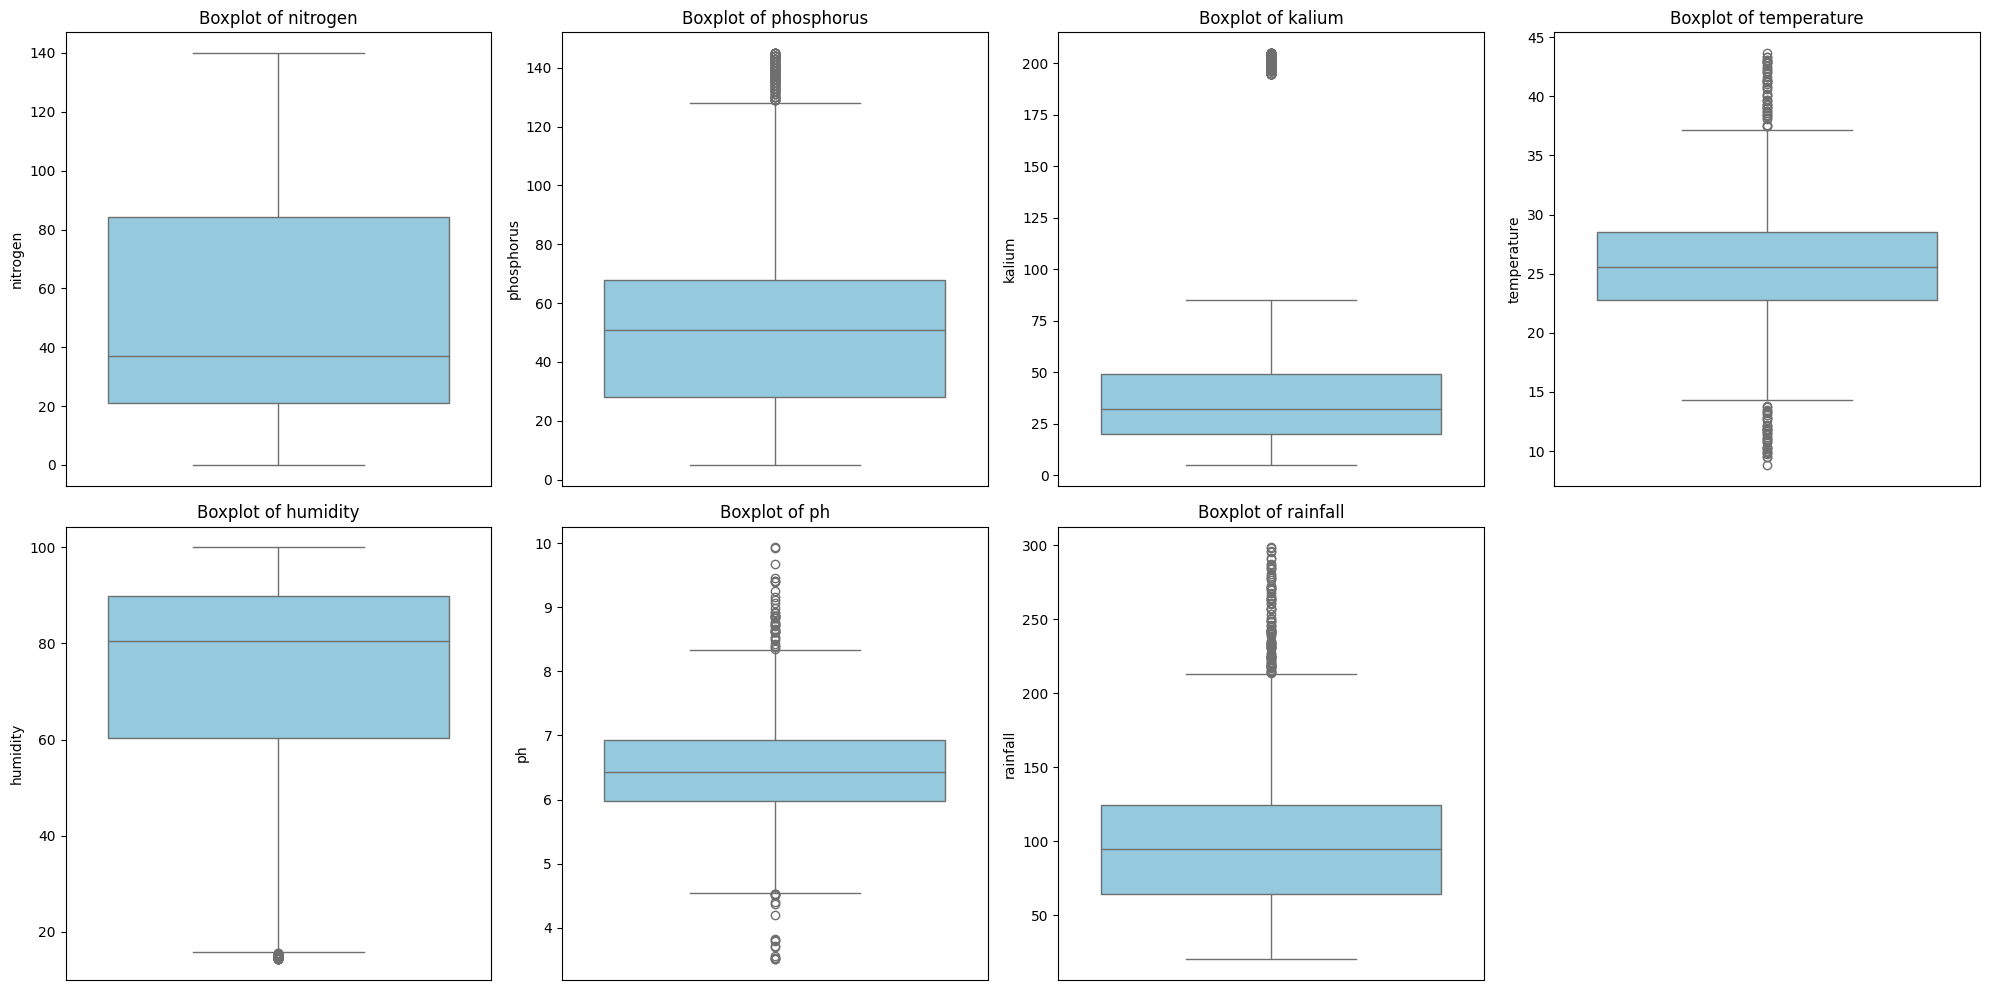

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt



## Check for Outliers using Box Plots
plt.figure(figsize=(20,10))

# Create subplots for each numerical column
for i, column in enumerate(['nitrogen', 'phosphorus', 'kalium', 'temperature', 'humidity', 'ph', 'rainfall'], 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[column], color='skyblue')
    plt.title(f'Boxplot of {column}')
    plt.xticks([])

plt.tight_layout()
plt.show()


📌 __Penjelasan__:

Pada kode di atas, kita mengimpor library visualisasi yaitu ```seaborn``` dan ```matplotlib.pyplot``` untuk membuat grafik.

Kemudian, kita melakukan deteksi outlier (nilai pencilan) menggunakan boxplot untuk setiap kolom numerik pada dataset (```N```, ```P```, ```K```, ```temperature```, ```humidity```, ```ph```, ```rainfall```).

```plt.figure(figsize=(20,10))``` untuk mengatur ukuran figure supaya lebih lebar.

```for i, column in enumerate(...):``` untuk membuat loop pada pembuatan boxplot di setiap kolom numerik.

```sns.boxplot()``` untuk membuat boxplot dari kolom yang sedang diproses.

```plt.title()``` untuk memberikan judul pada masing-masing plot.

```plt.tight_layout()``` untuk mengatur tata letak agar plot tidak saling tumpang tindih.

```plt.show()``` untuk menampilkan seluruh plot dalam satu gambar.

Tujuan boxplot adalah untuk melihat distribusi data dan mendeteksi outlier secara visual.

In [8]:
## Outlier Detection using IQR
def detect_outliers(df, column):
    # 1. Hitung Q1 (persentil 25) dan Q3 (persentil 75)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    # 2. Hitung IQR (Interquartile Range)
    IQR = Q3 - Q1
    
    # 3. Tentukan batas bawah dan batas atas (aturan 1.5 * IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return len(outliers)

numerical_columns = ['nitrogen', 'phosphorus', 'kalium', 'temperature', 'humidity', 'ph', 'rainfall']
for column in numerical_columns:
    n_outliers = detect_outliers(df, column)
    print(f"Number of outliers in {column}: {n_outliers}")

Number of outliers in nitrogen: 0
Number of outliers in phosphorus: 138
Number of outliers in kalium: 200
Number of outliers in temperature: 86
Number of outliers in humidity: 30
Number of outliers in ph: 57
Number of outliers in rainfall: 100


<img src="https://github.com/epsindo-ai/bootcamp_PNP2/blob/main/training-d3/sesi_1/iqr.png?raw=true" alt="Boxplot Outlier Detection">

📌 __Penjelasan__:

Pada kode di atas, kita melakukan deteksi outlier menggunakan metode __IQR (Interquartile Range)__.

Fungsi ```detect_outliers()``` digunakan untuk menghitung berapa banyak outlier di setiap kolom numerik.

```Q1``` dan ```Q3``` Mengambil kuartil pertama (25%) dan kuartil ketiga (75%).

```IQR``` Selisih antara Q3 dan Q1 (IQR = Q3 - Q1).

```lower_bound``` dan ```upper_bound``` Batas bawah dan batas atas. Nilai di luar batas ini dianggap outlier.

Baris yang nilainya lebih kecil dari batas bawah atau lebih besar dari batas atas dikategorikan sebagai outlier.
Loop for akan mengecek setiap kolom numerik dalam list ```numerical_columns```.

```print()``` akan menampilkan jumlah outlier yang ditemukan di setiap kolom.

Tujuan kode ini adalah untuk membantu kita mengetahui apakah ada nilai ekstrem dalam data yang bisa mempengaruhi analisis atau model machine learning.

✅ Cara penanganan outlier tergantung kasus:

1. Hapus, jika outlier adalah data error.
2. Imputasi, jika outlier relevan tapi ekstrem.

In [9]:
def handle_outliers(df, kolom_list, metode="median"):
    """
    Menangani outlier dalam beberapa kolom dengan opsi mengganti dengan median atau menghapusnya.

    Return:
    DataFrame yang sudah dibersihkan.
    """

    for kolom in kolom_list:
        # 1. Hitung Q1 (persentil 25) dan Q3 (persentil 75)
        Q1 = df[kolom].quantile(0.25)
        Q3 = df[kolom].quantile(0.75)

        # 2. Hitung IQR (Interquartile Range)
        IQR = Q3 - Q1

        # 3. Tentukan batas bawah dan batas atas (aturan 1.5 * IQR)
        batas_bawah = Q1 - 1.5 * IQR
        batas_atas = Q3 + 1.5 * IQR

        if metode == "median":
            # Ganti outlier dengan median
            nilai_median = df[kolom].median()
            # Bulatkan ke integer untuk kolom yang bertipe int
            if df[kolom].dtype == 'int64':
                nilai_median = int(round(nilai_median))
            df.loc[(df[kolom] < batas_bawah) | (df[kolom] > batas_atas), kolom] = nilai_median
            
        elif metode == "mean":
            # Ganti outlier dengan mean
            nilai_mean = df[kolom].mean()
            # Bulatkan ke integer untuk kolom yang bertipe int
            if df[kolom].dtype == 'int64':
                nilai_mean = int(round(nilai_mean))
            df.loc[(df[kolom] < batas_bawah) | (df[kolom] > batas_atas), kolom] = nilai_mean

        elif metode == "hapus":
            # Hapus baris yang mengandung outlier
            df = df[~((df[kolom] < batas_bawah) | (df[kolom] > batas_atas))]

    return df

# Contoh penggunaan
kolom_outlier = ['humidity', 'ph', 'rainfall', 'temperature', 'phosphorus', 'kalium']
df_mean = handle_outliers(df, kolom_outlier, metode="mean") # Ganti outlier dengan mean
# df_median = handle_outliers(df, kolom_outlier, metode="median")  # Ganti outlier dengan median
# df_clean = handle_outliers(df, kolom_outlier, metode="hapus")  # Hapus outlier


In [10]:
df.describe()

,nitrogen,phosphorus,kalium,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,48.038636,34.330909,25.534157,72.253575,6.446596,96.969302
std,36.917334,24.700293,16.613536,4.146870,21.245629,0.663059,44.987625
min,0.000000,5.000000,5.000000,14.343205,15.755940,4.546466,20.211267
25%,21.000000,28.000000,20.000000,23.033701,61.173654,5.992383,64.551686
50%,37.000000,51.000000,32.000000,25.616244,80.473146,6.435852,94.867624
75%,84.250000,63.000000,48.000000,28.234328,89.948771,6.877817,116.049192
max,140.000000,128.000000,85.000000,37.131650,99.981876,8.340398,213.356092


📌 __Penjelasan__:

Pada kode ```df.describe()```, kita melakukan ringkasan statistik deskriptif terhadap kolom-kolom numerik dalam dataset.

In [11]:
df.columns

Index(['nitrogen', 'phosphorus', 'kalium', 'temperature', 'humidity', 'ph',
       'rainfall', 'label'],
      dtype='object')

📌 __Penjelasan__:

Pada kode ```df.columns```, kita memeriksa nama kolom apa saja yang ada pada dataset.

In [12]:
df.shape

(2200, 8)

📌 __Penjelasan__:

Pada kode ```df.shape```, kita memeriksa jumlah dari dataset (banyak baris, banyak kolom).

In [13]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

📌 __Penjelasan__:

Kode ```df['label'].unique()``` digunakan untuk menampilkan semua nilai unik (distinct values) yang terdapat pada kolom ```label``` di dataset.

In [14]:
df['label'].nunique()

22

📌 __Penjelasan__:

Kode ```df['label'].nunique()``` digunakan untuk menghitung jumlah nilai unik atau kategori berbeda yang ada di kolom label.

In [15]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

📌 __Penjelasan__:

Kode ```df['label'].value_counts()``` digunakan untuk menghitung jumlah kemunculan (frekuensi) dari setiap kategori unik yang ada di kolom label.

<Axes: xlabel='ph', ylabel='Count'>

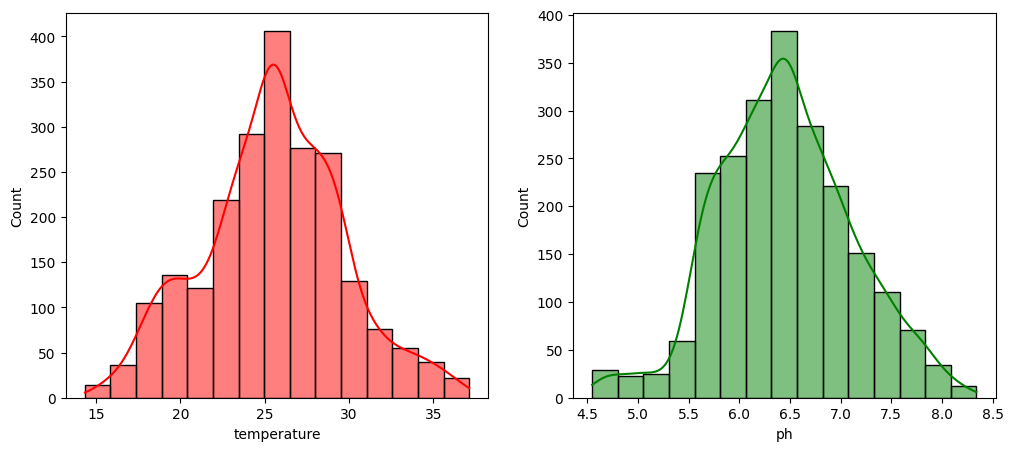

In [16]:
plt.figure(figsize=(12,5))

# Temperature distribution
plt.subplot(1, 2, 1)
sns.histplot(df['temperature'], color="red", bins=15, kde=True, alpha=0.5)

# pH distribution
plt.subplot(1, 2, 2)
sns.histplot(df['ph'], color="green", bins=15, kde=True, alpha=0.5)

📌 __Penjelasan__:

Kode di atas digunakan untuk membuat visualisasi distribusi data pada dua variabel berbeda, yaitu ```temperature``` dan ```ph```, dengan histogram dan kurva KDE (Kernel Density Estimation) secara berdampingan.

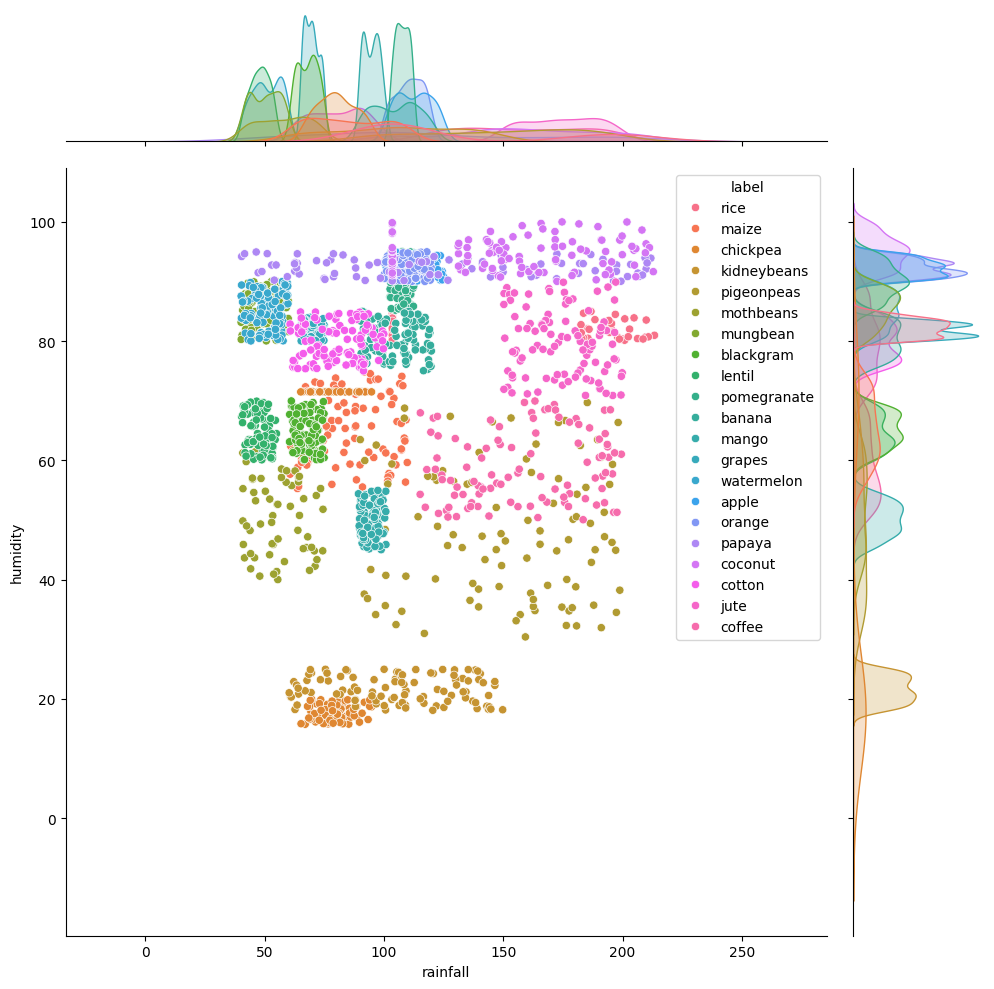

In [17]:
sns.jointplot(x="rainfall",y="humidity",data=df[(df['temperature']<40) & 
                                                  (df['rainfall']>40)],height=10,hue="label")

📌 __Penjelasan__:

Kode di atas digunakan untuk membuat visualisasi hubungan (relasi) antara dua variabel numerik ```rainfall``` dan ```humidity``` menggunakan ```sns.jointplot()```, yang secara otomatis menampilkan scatterplot di tengah, dan distribusi (histogram) di sumbu X dan Y.

Selain itu, grafik ini juga dikelompokkan berdasarkan kategori tanaman (label) agar lebih informatif.

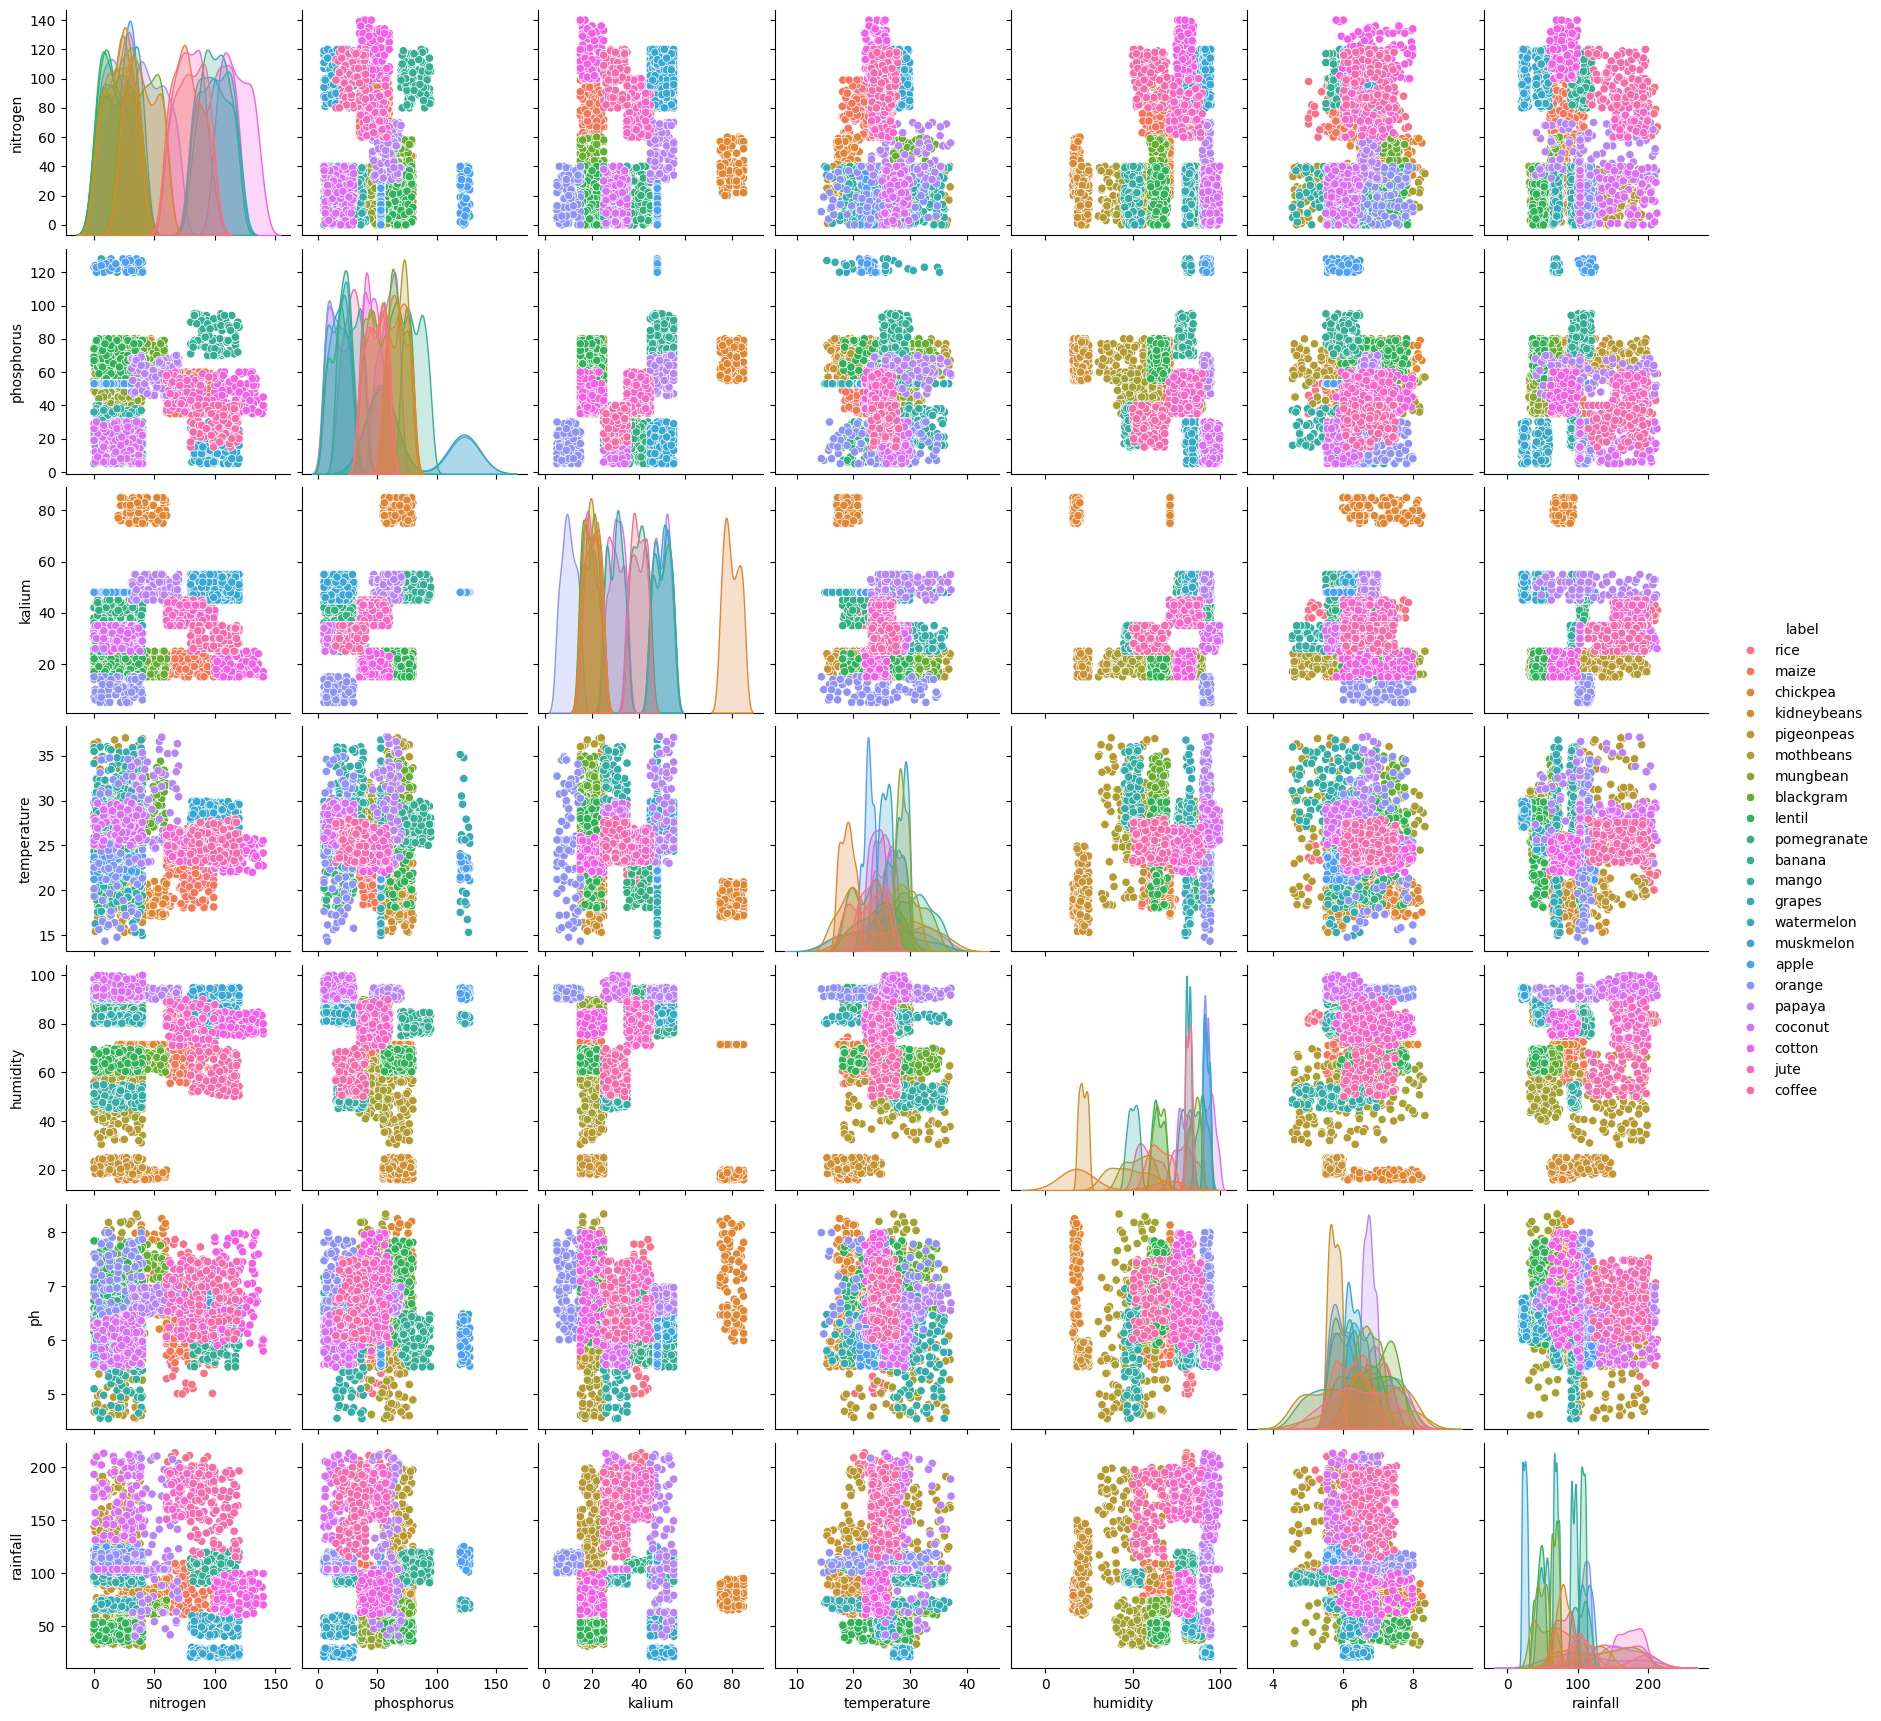

In [18]:
sns.pairplot(df,hue = 'label')

📌 __Penjelasan__:

Kode ```sns.pairplot(df, hue='label')``` digunakan untuk membuat visualisasi multivariat dari seluruh kombinasi fitur numerik di dataset, dengan membedakan kelompok berdasarkan nilai dari kolom ```label```.

<Axes: xlabel='label', ylabel='ph'>

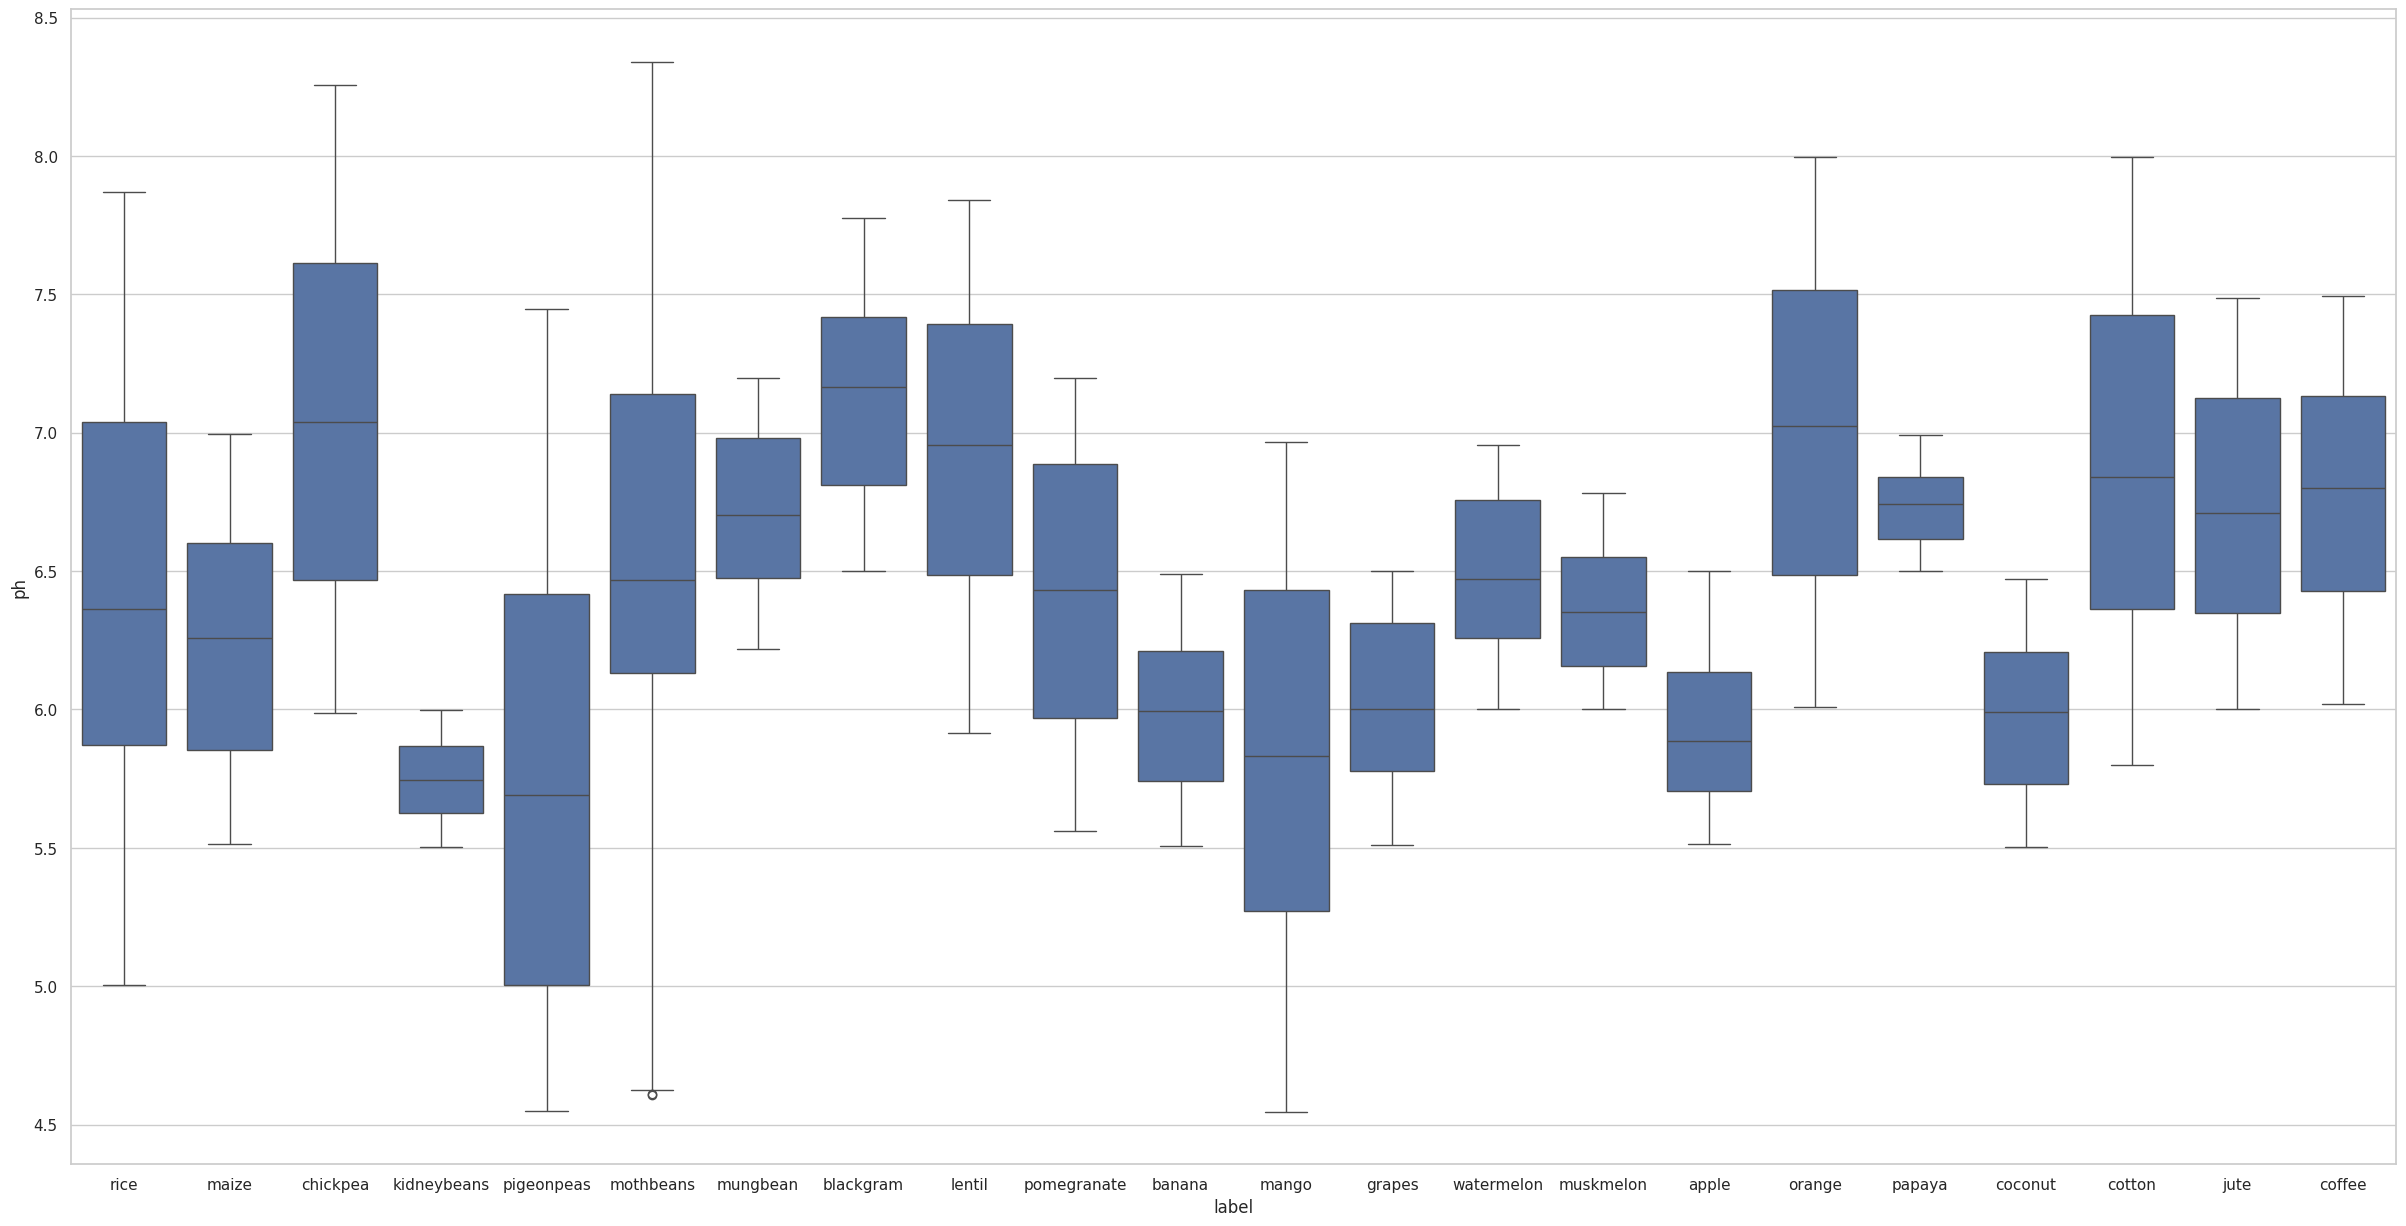

In [19]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(30,15))
sns.boxplot(x='label',y='ph',data=df)

📌 __Penjelasan__:

Kode berikut digunakan untuk membuat visualisasi boxplot dari kolom ```ph``` untuk masing-masing label tanaman, dengan tema tampilan grafis yang lebih estetik menggunakan Seaborn.

Fungsi dan Tujuan Visualisasi Ini adalah Untuk melihat penyebaran nilai ```pH``` pada masing-masing jenis tanaman (```label```), Jenis tanaman mana yang membutuhkan pH lebih tinggi/lebih rendah.

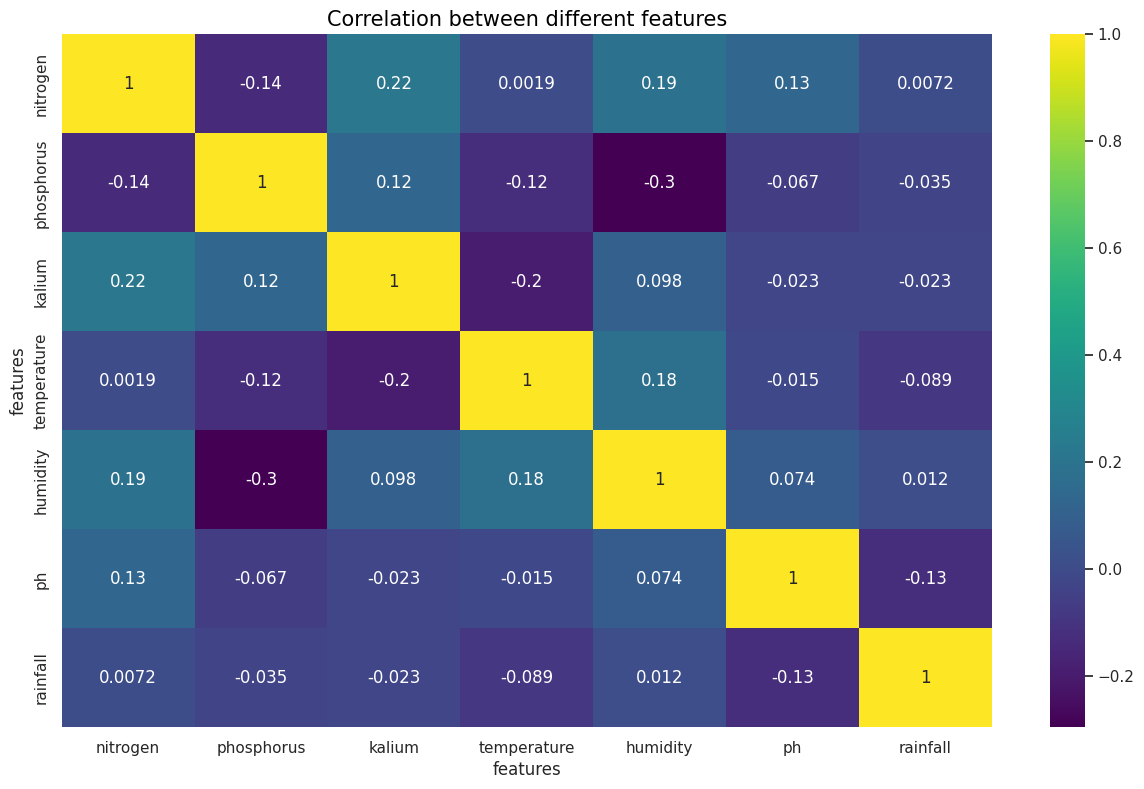

In [20]:
df_corr = df.drop(columns=["label"])

fig, ax = plt.subplots(1, 1, figsize=(15, 9))
sns.heatmap(df_corr.corr(), annot=True,cmap='viridis')
ax.set(xlabel='features')
ax.set(ylabel='features')

plt.title('Correlation between different features', fontsize = 15, c='black')
plt.show()

📌 __Penjelasan__:

Kode berikut digunakan untuk membuat heatmap korelasi antar fitur numerik dalam dataset, dengan label (```target```) dihapus terlebih dahulu karena bukan variabel numerik.

Fungsi dan Tujuan Visualisasi Ini:
1. Untuk memahami hubungan linear antar fitur numerik.
2. Nilai korelasi berkisar antara -1 hingga 1:
  * 1 → Korelasi positif sempurna (jika satu naik, yang lain ikut naik).
  * -1 → Korelasi negatif sempurna (jika satu naik, yang lain turun).
  * 0 → Tidak ada korelasi.
  

Membantu analisis Feature Selection yaitu memilih fitur penting untuk model machine learning.


In [21]:
df_summary = pd.pivot_table(df, index=['label'], aggfunc='mean')
df_summary.head()

,humidity,kalium,nitrogen,ph,phosphorus,rainfall,temperature
label,,,,,,,
apple,92.333383,48.00,20.80,5.929663,74.16,112.654779,22.630942
banana,80.358123,50.05,100.23,5.983893,82.01,104.626980,27.376798
blackgram,65.118426,19.24,40.02,7.133952,67.47,67.884151,29.973340
chickpea,33.839944,79.92,40.09,7.051092,67.79,80.058977,18.872847
coconut,94.844272,30.59,21.98,5.976562,16.93,158.140728,27.409892


📌 __Penjelasan__:

Pada kode di atas, kita membuat sebuah pivot table dari dataframe df untuk menganalisis nilai rata-rata tiap label (jenis tanaman).

In [22]:

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Bar(
    x=df_summary.index,
    y=df_summary['nitrogen'],
    name='Nitrogen',
    marker_color='mediumvioletred'
))
fig.add_trace(go.Bar(
    x=df_summary.index,
    y=df_summary['phosphorus'],
    name='Phosphorous',
    marker_color='springgreen'
))
fig.add_trace(go.Bar(
    x=df_summary.index,
    y=df_summary['kalium'],
    name='Kalium',
    marker_color='dodgerblue'
))

fig.update_layout(title="N-P-K values comparision between crops",
                  plot_bgcolor='white',
                  barmode='group',
                  xaxis_tickangle=-45)

fig.show()

📌 __Penjelasan__:

Kode di atas digunakan untuk membuat visualisasi perbandingan kandungan N-P-K (Nitrogen, Phosphorus, Kalium) pada berbagai tanaman, menggunakan Plotly.

Untuk membandingkan kebutuhan Nutrisi Tanaman pada berbagai jenis tanaman dan membantu memahami tanaman mana yang membutuhkan Nitrogen, Phosphorous, atau Potash lebih tinggi.

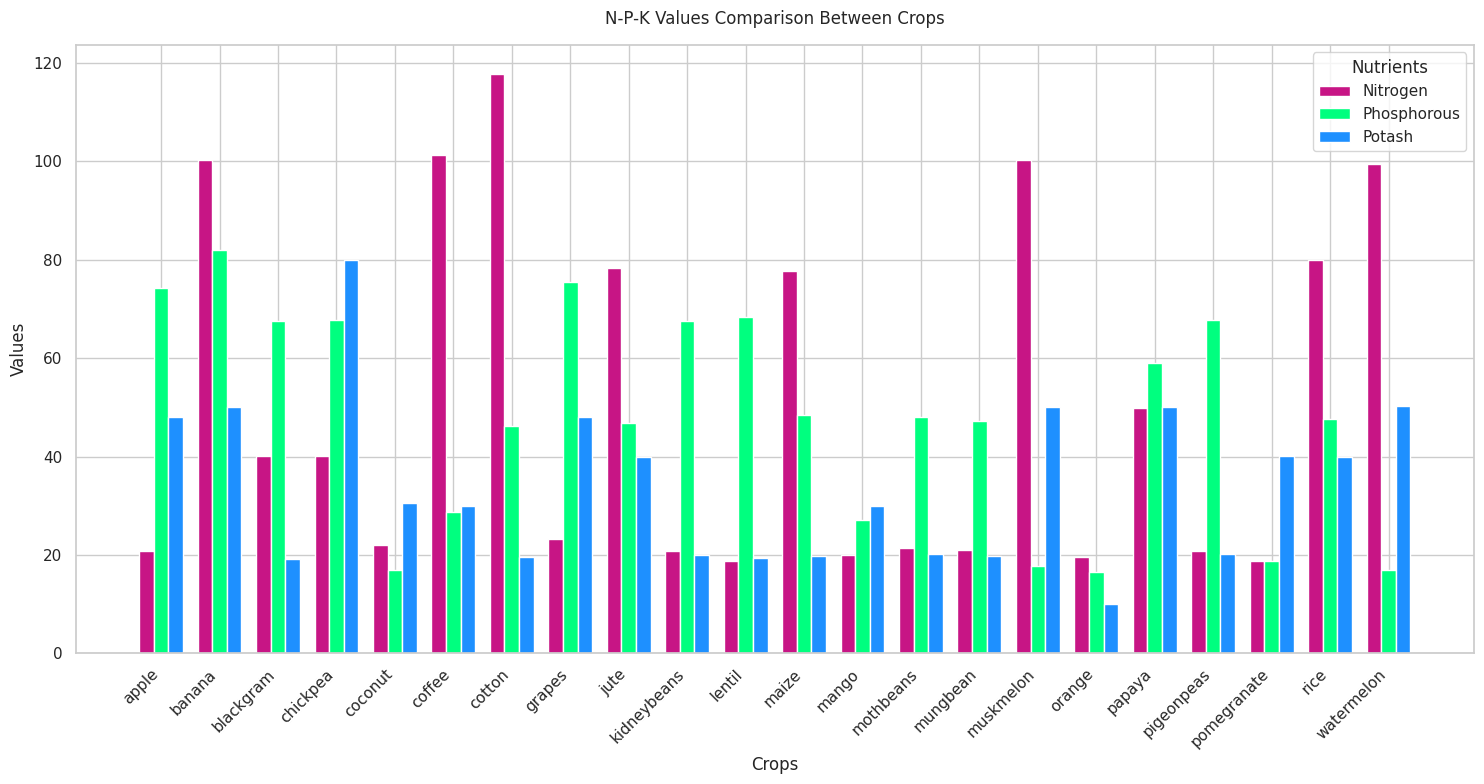

In [23]:
# Create the grouped bar plot
plt.figure(figsize=(15, 8))

# Plot each nutrient as a separate bar group
bar_width = 0.25
x = np.arange(len(df_summary.index))

plt.bar(x - bar_width, df_summary['nitrogen'], bar_width, label='Nitrogen', color='mediumvioletred')
plt.bar(x, df_summary['phosphorus'], bar_width, label='Phosphorous', color='springgreen')
plt.bar(x + bar_width, df_summary['kalium'], bar_width, label='Potash', color='dodgerblue')

# Customize the plot
plt.title('N-P-K Values Comparison Between Crops', fontsize=12, pad=15)
plt.xlabel('Crops')
plt.ylabel('Values')
plt.xticks(x, df_summary.index, rotation=45, ha='right')
plt.legend(title='Nutrients')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

📌 __Penjelasan__:

Kode ini digunakan untuk membuat Grouped Bar Plot (diagram batang berkelompok) yang membandingkan nilai rata-rata Nutrisi N-P-K (Nitrogen, Phosphorous, Potash) untuk setiap jenis tanaman (label) yang ada di df_summary.

## Feature Selection

In [24]:
# features = df[['N', 'P','K','temperature', 'humidity', 'ph', 'rainfall']]
features = df.drop(columns=['label'])
target = df['label']

In [25]:
acc = []
model = []

In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features,target,test_size = 0.2,random_state=42)

📌 __Penjelasan__:

Kode ini mempersiapkan data input (```features```) dan target (```label```), lalu membaginya menjadi data training dan data testing sebelum model machine learning dibangun. dan menyimpan ke dalam varibel array ```acc``` untuk akurasi ```model```, dan variabel model untuk menyimpan nama model. 

## 🚀Model Selection & Training

### Classification Algorithms

#### K-Nearest Neighbor

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import classification_report

knn = KNeighborsClassifier()

knn.fit(x_train,y_train)

predicted_values = knn.predict(x_test)

x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)
model.append('K Nearest Neighbours')
print("KNN Accuracy is: ", x)

print(classification_report(y_test,predicted_values))

KNN Accuracy is:  0.9636363636363636
              precision    recall  f1-score   support

       apple       1.00      0.96      0.98        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      0.96      0.98        27
      coffee       1.00      0.94      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.73      0.96      0.83        23
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00 

📌 __Penjelasan__:

Kode ini membuat, melatih, dan mengevaluasi model K-Nearest Neighbors untuk klasifikasi tanaman berdasarkan dataset yang sudah disiapkan sebelumnya. Setelah model diprediksi, akurasinya diukur dan performa detail tiap kelas dievaluasi lewat classification_report.

In [28]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(knn,features,target,cv=5)
print('Cross validation score: ',score)

Cross validation score:  [0.96363636 0.97272727 0.96590909 0.97045455 0.96818182]


📌 __Penjelasan__:

```cross_val_score()``` akan:

1. Membagi dataset (features dan target) menjadi 5 bagian (folds) karena cv=5.
2. Melatih dan menguji model knn sebanyak 5 kali, setiap kali menggunakan fold yang berbeda sebagai data uji, dan sisanya sebagai data latih.
3. Mengembalikan 5 skor akurasi (satu untuk tiap fold).

In [29]:
#Print Train Accuracy
knn_train_accuracy = knn.score(x_train,y_train)
print("knn_train_accuracy = ",knn.score(x_train,y_train))
#Print Test Accuracy
knn_test_accuracy = knn.score(x_test,y_test)
print("knn_test_accuracy = ",knn.score(x_test,y_test))

knn_train_accuracy =  0.9829545454545454
knn_test_accuracy =  0.9636363636363636


📌 __Penjelasan__:

```knn.score(x_train, y_train)``` menghitung akurasi model KNN pada data latih (train set).

```knn.score(x_test, y_test)``` menghitung akurasi model KNN pada data uji (test set).

* Train Accuracy terlalu tinggi + Test Accuracy rendah → indikasi overfitting (model hafal data train tapi jelek di data baru).
* Train & Test Accuracy sama-sama rendah → kemungkinan underfitting (model belum cukup belajar pola data).
* Train & Test Accuracy seimbang dan cukup tinggi → model punya generalization yang baik.

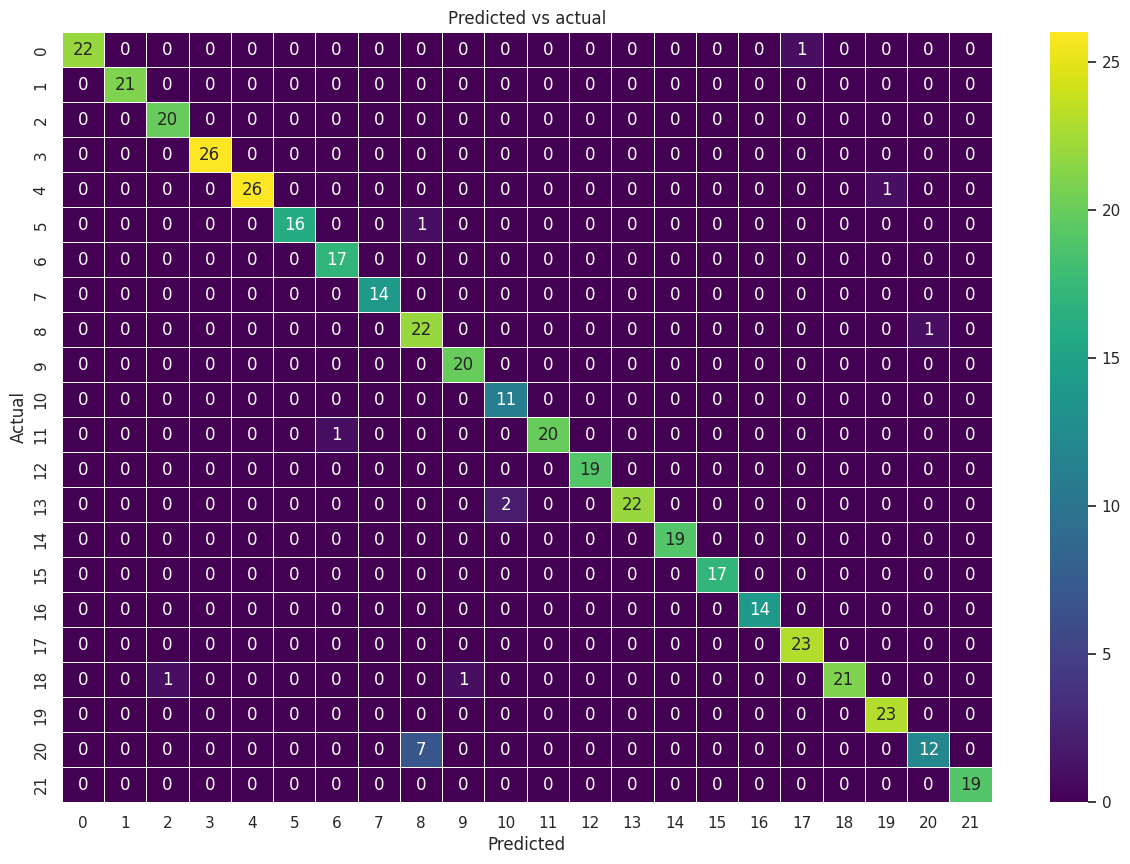

In [30]:
y_pred = knn.predict(x_test)
y_true = y_test

from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_true,y_pred)

f, ax = plt.subplots(figsize=(15,10))
sns.heatmap(cm_knn, annot=True, linewidth=0.5, fmt=".0f",cmap='viridis', ax = ax)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Predicted vs actual')
plt.show()

📌 __Penjelasan__:

Membuat Confusion Matrix (```cm_knn```), yaitu tabel yang menunjukkan jumlah prediksi benar dan salah model untuk setiap kelas.

#### Hyperparameter Tuning

In [31]:
mean_acc = np.zeros(20)
for i in range(1,21):
    #Train Model and Predict  
    knn = KNeighborsClassifier(n_neighbors = i).fit(x_train,y_train)
    yhat= knn.predict(x_test)
    mean_acc[i-1] = metrics.accuracy_score(y_test, yhat)

mean_acc

array([0.96363636, 0.95681818, 0.96590909, 0.96363636, 0.96363636,
       0.96363636, 0.96363636, 0.96136364, 0.96136364, 0.95454545,
       0.95227273, 0.95      , 0.95227273, 0.94318182, 0.94545455,
       0.93409091, 0.93409091, 0.92727273, 0.92954545, 0.92954545])

📌 __Penjelasan__:

Untuk menguji performa model K-Nearest Neighbors (KNN) dengan berbagai jumlah tetangga terdekat (```n_neighbors```) dan mengetahui berapa nilai K terbaik agar akurasi model paling tinggi.

Nilai akurasi terbaik ada di ```n_neighbors``` = 3 dan ```n_neighbors``` = 5, dengan akurasi 97.04% (0.97045455).

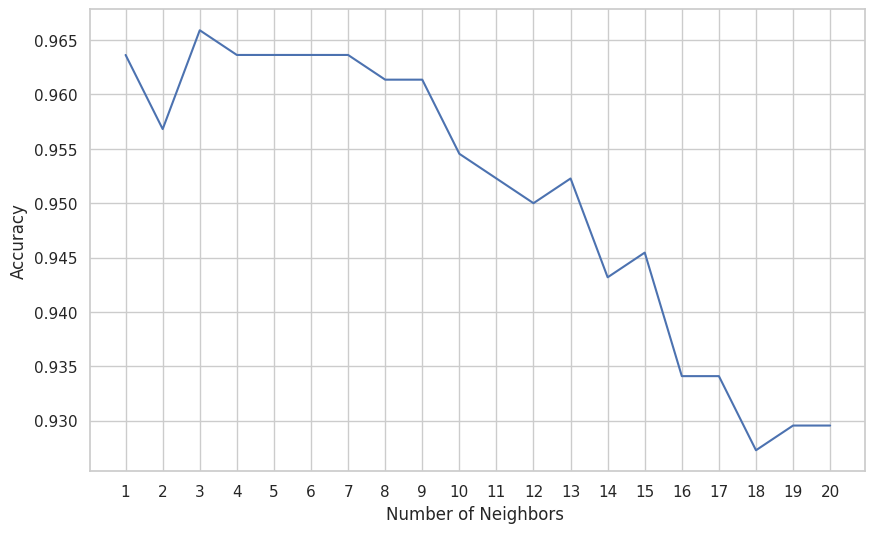

In [32]:
loc = np.arange(1,21,step=1.0)
plt.figure(figsize = (10, 6))
plt.plot(range(1,21), mean_acc)
plt.xticks(loc)
plt.xlabel('Number of Neighbors ')
plt.ylabel('Accuracy')
plt.show()

📌 __Penjelasan__:

Plot akurasi model KNN untuk tiap jumlah neighbour ```K```.

In [33]:
from sklearn.model_selection import GridSearchCV

grid_params = { 'n_neighbors' : [12,13,14,15,16,17,18],
               'weights' : ['uniform','distance'],
               'metric' : ['minkowski','euclidean','manhattan']}

gs = GridSearchCV(KNeighborsClassifier(), grid_params, verbose = 1, cv=3, n_jobs = -1)

g_res = gs.fit(x_train, y_train)

print("Best Score: ",g_res.best_score_)
print("Best Parameter: ",g_res.best_params_)

Fitting 3 folds for each of 42 candidates, totalling 126 fits


Best Score:  0.9710275537673483
Best Parameter:  {'metric': 'manhattan', 'n_neighbors': 12, 'weights': 'distance'}


📌 __Penjelasan__:

Kode ini bertujuan mencari kombinasi hyperparameter terbaik untuk model K-Nearest Neighbors (KNN) menggunakan ```GridSearchCV```.
Hyperparameter tuning ini membantu mendapatkan model dengan akurasi optimal.

```GridSearchCV``` mencari kombinasi hyperparameter terbaik dengan cara mengevaluasi performa model berdasarkan metrik evaluasi di setiap kombinasi yang dicoba.

In [34]:
knn_1 = KNeighborsClassifier(n_neighbors = 12, weights = 'distance',algorithm = 'brute',metric = 'manhattan')
knn_1.fit(x_train, y_train)

,n_neighbors,12
,weights,'distance'
,algorithm,'brute'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


📌 __Penjelasan__:

Melakukan modeling dengan menggunakan parameter yang optimal.

In [35]:
# Training & Testing accuracy after applying hyper parameter
knn_train_accuracy = knn_1.score(x_train,y_train)
print("knn_train_accuracy = ",knn_1.score(x_train,y_train))
#Print Test Accuracy
knn_test_accuracy = knn_1.score(x_test,y_test)
print("knn_test_accuracy = ",knn_1.score(x_test,y_test))

knn_train_accuracy =  1.0
knn_test_accuracy =  0.9704545454545455


📌 __Penjelasan__:

Melihat hasil evaluasi akurasi performa model yang telah dibangun.

### Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(criterion="entropy",random_state=2,max_depth=10)

DT.fit(x_train,y_train)

predicted_values = DT.predict(x_test)
x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)
model.append('Decision Tree')
print("Decision Tree's Accuracy is: ", x*100)

print(classification_report(y_test,predicted_values))

Decision Tree's Accuracy is:  98.63636363636363
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.91      1.00      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      0.96      0.98        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      0.95      0.97        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       0.95      0.88      0.91        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00

In [37]:
score = cross_val_score(DT, features, target,cv=5)
print('Cross validation score: ',score)

#Print Train Accuracy
dt_train_accuracy = DT.score(x_train,y_train)
print("Training accuracy = ",DT.score(x_train,y_train))
#Print Test Accuracy
dt_test_accuracy = DT.score(x_test,y_test)
print("Testing accuracy = ",DT.score(x_test,y_test))

Cross validation score:  [0.98863636 0.96818182 0.98409091 0.98863636 0.97727273]
Training accuracy =  0.9960227272727272
Testing accuracy =  0.9863636363636363


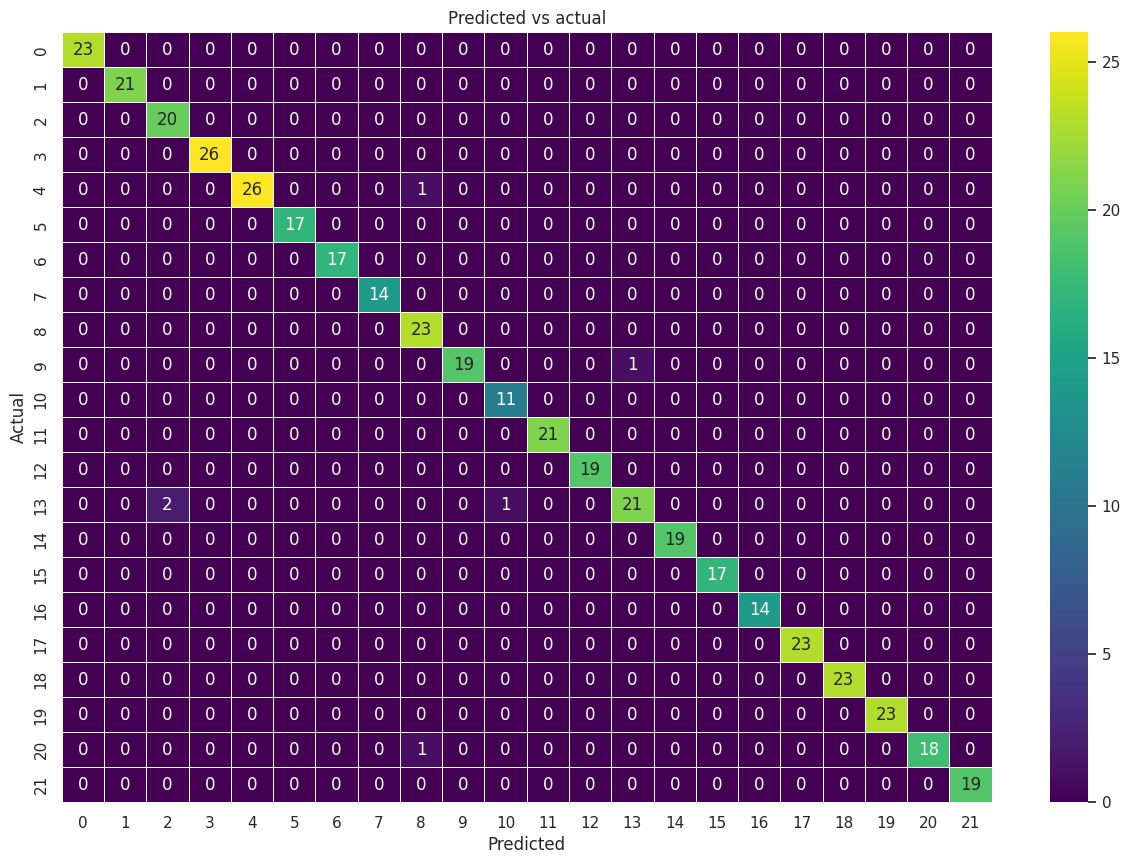

In [38]:
y_pred = DT.predict(x_test)
y_true = y_test

from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_true,y_pred)

f, ax = plt.subplots(figsize=(15,10))
sns.heatmap(cm_dt, annot=True, linewidth=0.5, fmt=".0f",  cmap='viridis', ax = ax)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title('Predicted vs actual')
plt.show()

### Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=20, random_state=0)
RF.fit(x_train,y_train)

predicted_values = RF.predict(x_test)

x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)
model.append('RF')
print("Random Forest Accuracy is: ", x)

print(classification_report(y_test, predicted_values))

Random Forest Accuracy is:  0.9886363636363636
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.88      0.96      0.92        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00 

In [40]:
score = cross_val_score(RF,features,target,cv=5)
print('Cross validation score: ',score)

#Print Train Accuracy
rf_train_accuracy = RF.score(x_train,y_train)
print("Training accuracy = ",RF.score(x_train,y_train))
#Print Test Accuracy
rf_test_accuracy = RF.score(x_test,y_test)
print("Testing accuracy = ",RF.score(x_test,y_test))

Cross validation score:  [0.99772727 0.99318182 0.99545455 0.99318182 0.98863636]
Training accuracy =  1.0
Testing accuracy =  0.9886363636363636


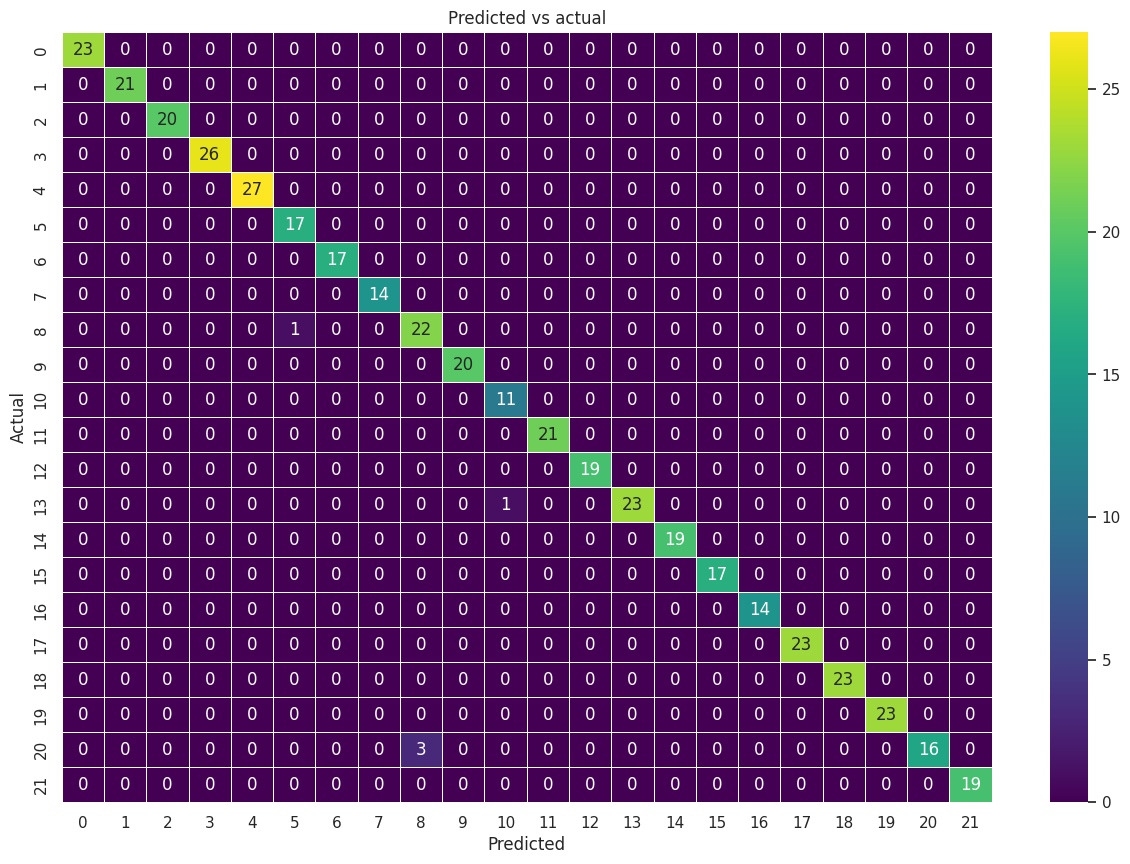

In [41]:
y_pred = RF.predict(x_test)
y_true = y_test

from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_true,y_pred)

f, ax = plt.subplots(figsize=(15,10))
sns.heatmap(cm_rf, annot=True, linewidth=0.5, fmt=".0f",  cmap='viridis', ax = ax)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title('Predicted vs actual')
plt.show()

## Comparing Models KNN, Decision Tree, Random Forest

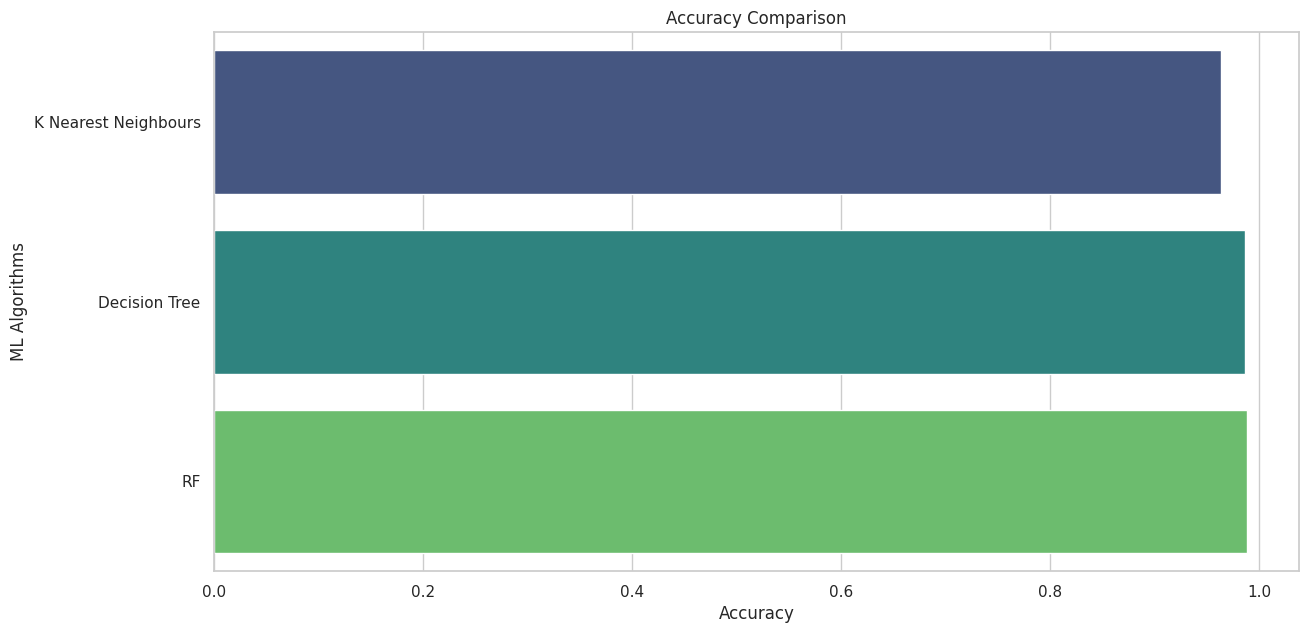

In [42]:
plt.figure(figsize=[14,7],dpi = 100, facecolor='white')
plt.title('Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('ML Algorithms')
sns.barplot(x=acc, y=model, hue=model, palette='viridis', legend=False)
plt.savefig('plot.png', dpi=300, bbox_inches='tight')

📌 __Penjelasan__:

Membandingkan akurasi setiap model terhadap dataset.

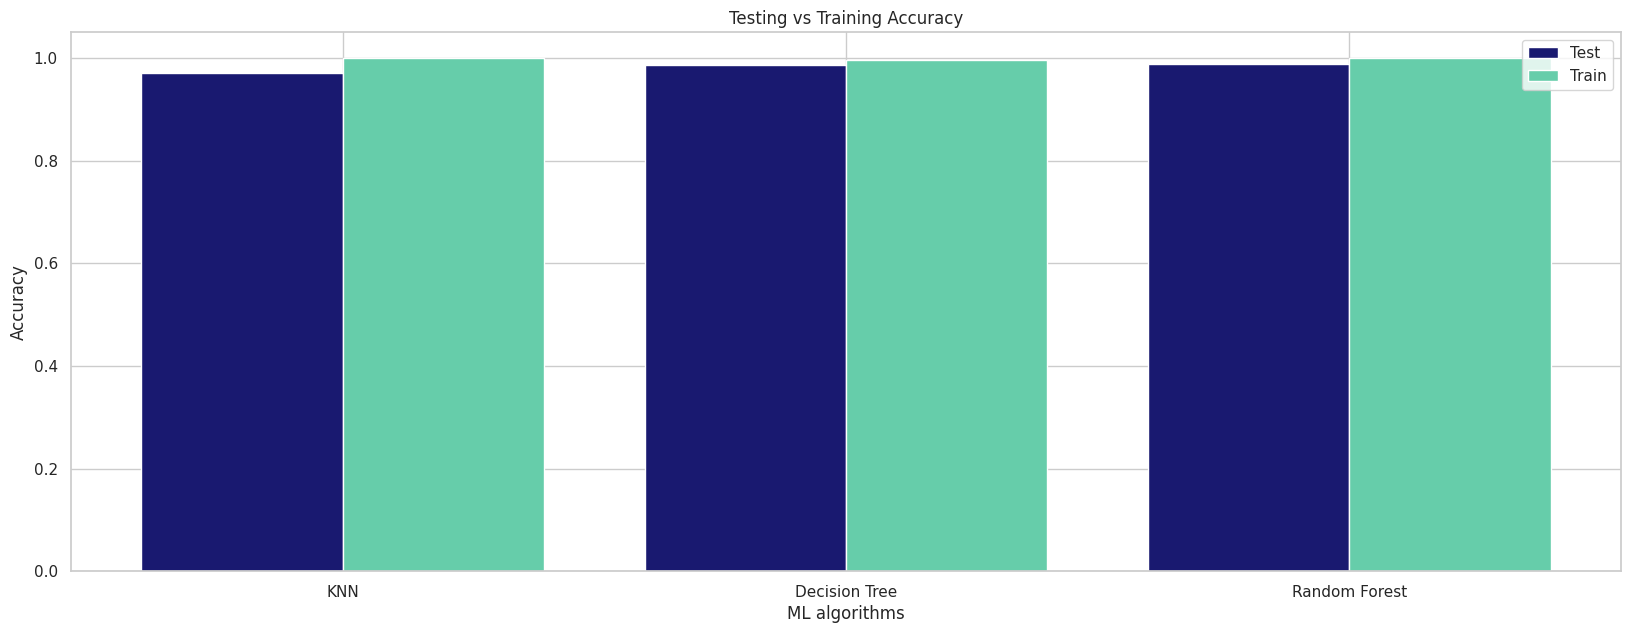

In [43]:
label = ['KNN', 'Decision Tree','Random Forest']
Test = [knn_test_accuracy, dt_test_accuracy,rf_test_accuracy]
Train = [knn_train_accuracy,  dt_train_accuracy, rf_train_accuracy]

f, ax = plt.subplots(figsize=(20,7)) # set the size that you'd like (width, height)
X_axis = np.arange(len(label))
plt.bar(X_axis - 0.2,Test, 0.4, label = 'Test', color=('midnightblue'))
plt.bar(X_axis + 0.2,Train, 0.4, label = 'Train', color=('mediumaquamarine'))

plt.xticks(X_axis, label)
plt.xlabel("ML algorithms")
plt.ylabel("Accuracy")
plt.title("Testing vs Training Accuracy")
plt.legend()
#plt.savefig('train vs test.png')
plt.show()

📌 __Penjelasan__:

Membandingkan akurasi testing dan akurasi training dari setiap model dengan grafik bar.

### Inference

In [44]:
columns = ['nitrogen', 'phosphorus', 'kalium', 'temperature', 'humidity', 'ph', 'rainfall']
data_sample=[90, 42, 43, 20.8, 82.3, 6.5, 202.93]

inference_test = pd.DataFrame([data_sample], columns=columns)

print(inference_test)
print("K-Nearest Neighbor Prediction: ", knn_1.predict(inference_test))
print("Decision Tree Prediction: ", DT.predict(inference_test))
print("Random Forest Prediction: ", RF.predict(inference_test))

   nitrogen  phosphorus  kalium  temperature  humidity   ph  rainfall
0        90          42      43         20.8      82.3  6.5    202.93
K-Nearest Neighbor Prediction:  ['rice']
Decision Tree Prediction:  ['rice']
Random Forest Prediction:  ['rice']


📌 __Penjelasan__:

melakukan simulasi inferensi/prediksi menggunakan data input baru dan melihat hasil prediksi dari masing-masing model machine learning yang sudah dilatih.